# Car Price Prediction - Exploratory Data Analysis (EDA)

This notebook explores the dataset to understand the key features affecting car prices.  
We will perform data inspection, visualization, and derive insights before building predictive models.

In [80]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plots
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,6)

## Step 2: Load Dataset
We load the dataset from the `data/` folder and preview the first few rows.

In [81]:
# Load dataset
data = pd.read_csv("../data/car_data.csv")   # Adjust path if needed
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Step 3: Basic Information
We check dataset shape, data types, and missing values.

In [82]:
print("Dataset Shape:", data.shape)
print("\nData Types:\n", data.dtypes)
print("\nMissing Values:\n", data.isnull().sum())

Dataset Shape: (301, 9)

Data Types:
 Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type            str
Selling_type         str
Transmission         str
Owner              int64
dtype: object

Missing Values:
 Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


## Step 4: Descriptive Statistics
We summarize numerical features and categorical distributions.

In [83]:
# Summary statistics
data.describe()

# Example categorical distribution using Fuel_Type
print("\nFuel Type Distribution:\n", data['Fuel_Type'].value_counts())

# Example categorical distribution using Transmission
print("\nTransmission Distribution:\n", data['Transmission'].value_counts())

# If you want to analyze Brand (derived from Car_Name)
data['Brand'] = data['Car_Name'].apply(lambda x: x.split()[0])
print("\nBrand Distribution:\n", data['Brand'].value_counts())


Fuel Type Distribution:
 Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

Transmission Distribution:
 Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

Brand Distribution:
 Brand
city        26
Bajaj       25
corolla     17
Royal       17
Honda       17
Hero        15
verna       14
fortuner    11
etios       11
brio        10
ciaz         9
innova       9
i20          9
Yamaha       8
TVS          8
grand        8
amaze        7
jazz         7
sx4          6
alto         6
ertiga       6
eon          6
swift        5
i10          5
ritz         4
wagon        4
dzire        4
KTM          4
Activa       3
xcent        3
creta        3
elantra      2
vitara       1
s            1
ignis        1
800          1
baleno       1
omni         1
camry        1
land         1
UM           1
Hyosung      1
Mahindra     1
Suzuki       1
Name: count, dtype: int64


## Step 5: Univariate Analysis
We analyze individual features using histograms and count plots.

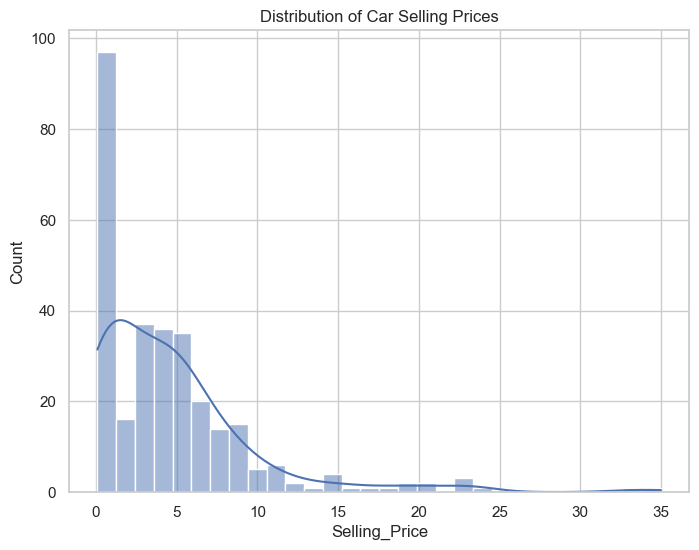

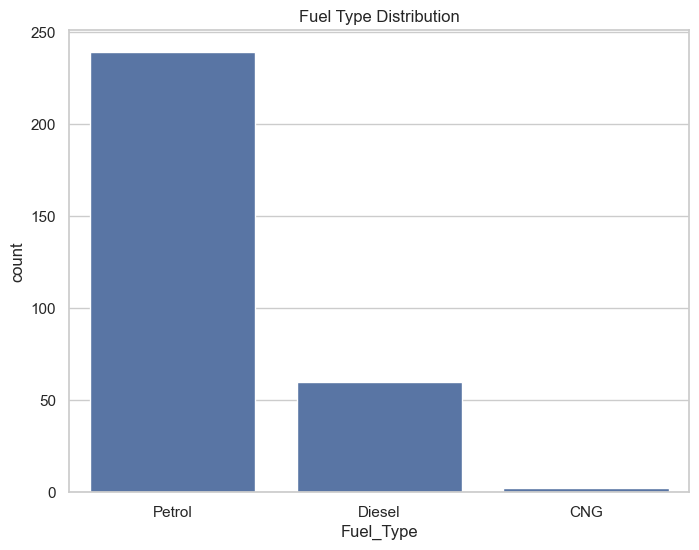

In [84]:
# Price distribution (Selling_Price column)
sns.histplot(data['Selling_Price'], bins=30, kde=True)
plt.title("Distribution of Car Selling Prices")
plt.show()

# Fuel type distribution (Fuel_Type column)
sns.countplot(x='Fuel_Type', data=data)
plt.title("Fuel Type Distribution")
plt.show()

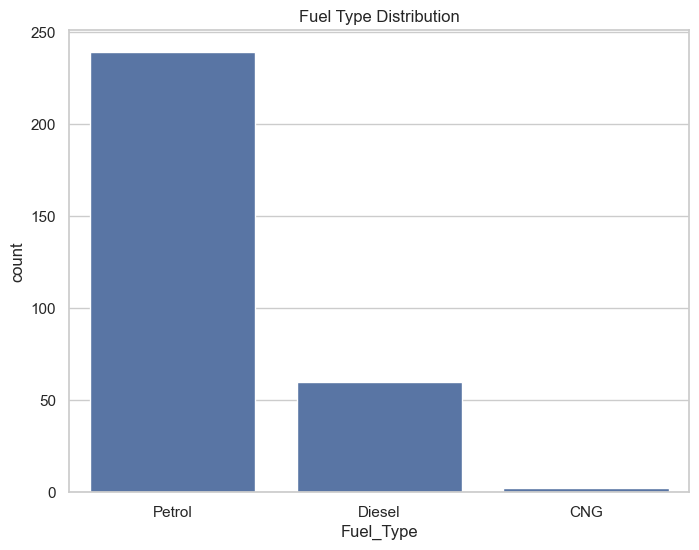

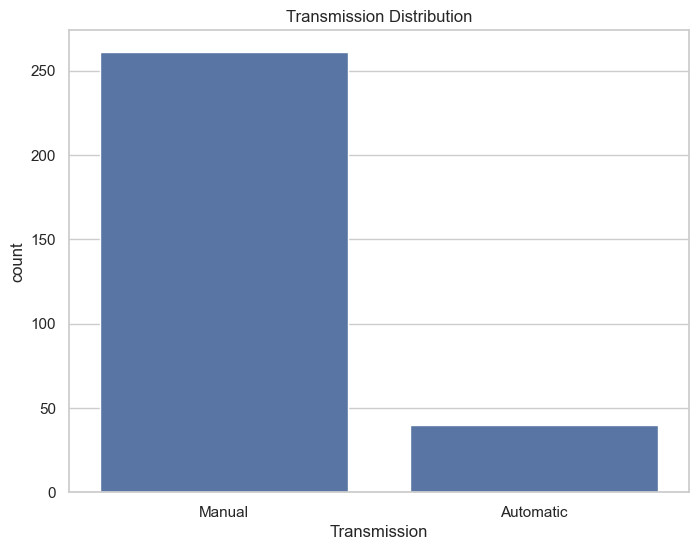

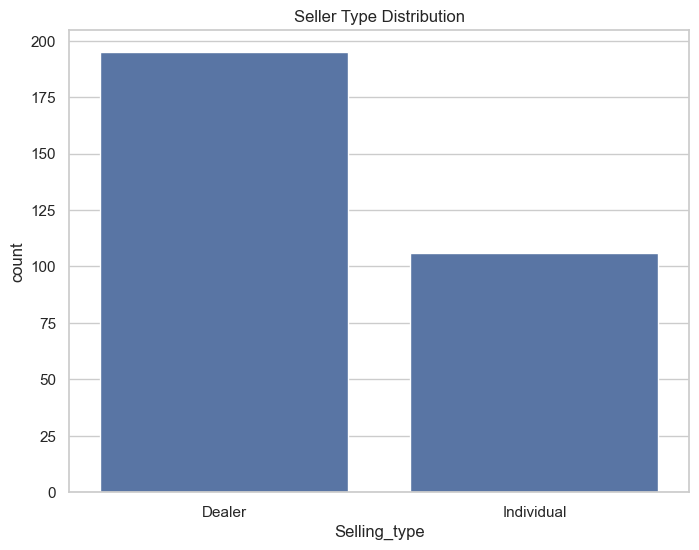

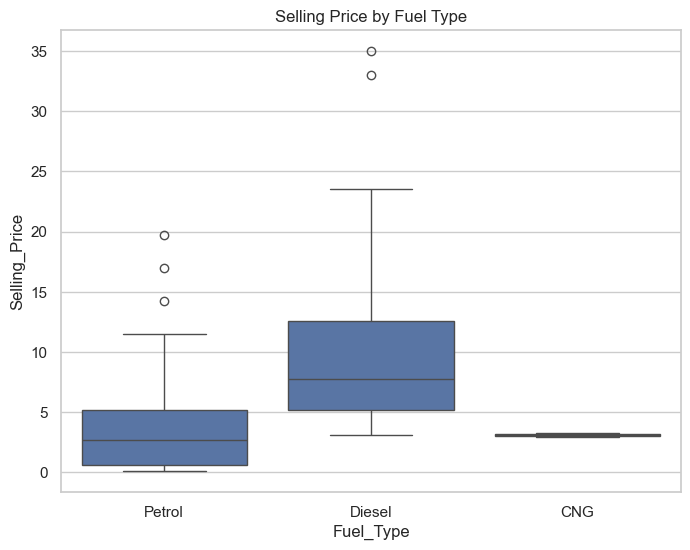

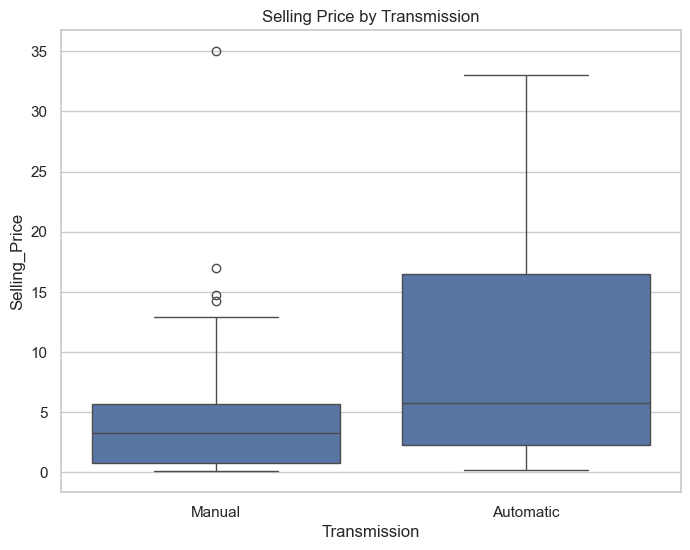

In [85]:
# Categorical distributions

# Fuel Type Distribution
sns.countplot(x='Fuel_Type', data=data)
plt.title("Fuel Type Distribution")
plt.show()

# Transmission Distribution
sns.countplot(x='Transmission', data=data)
plt.title("Transmission Distribution")
plt.show()

# Seller Type Distribution
sns.countplot(x='Selling_type', data=data)
plt.title("Seller Type Distribution")
plt.show()

# Selling Price by Fuel Type
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=data)
plt.title("Selling Price by Fuel Type")
plt.show()

# Selling Price by Transmission
sns.boxplot(x='Transmission', y='Selling_Price', data=data)
plt.title("Selling Price by Transmission")
plt.show()

## Step 6: Bivariate Analysis
We explore relationships between features and car price.

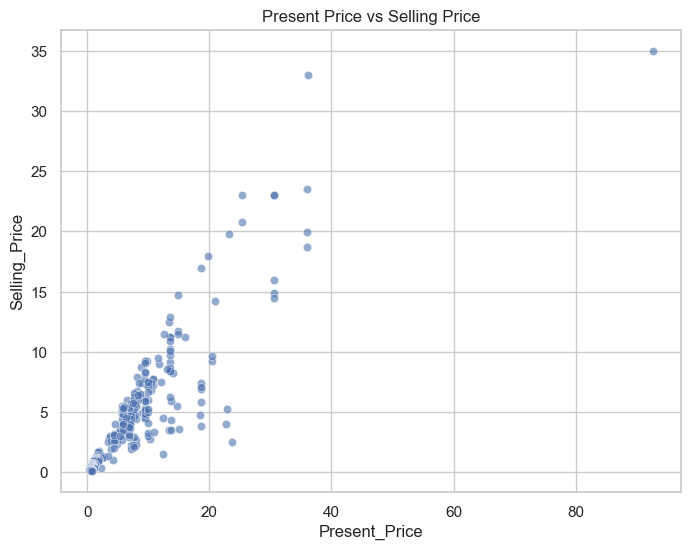

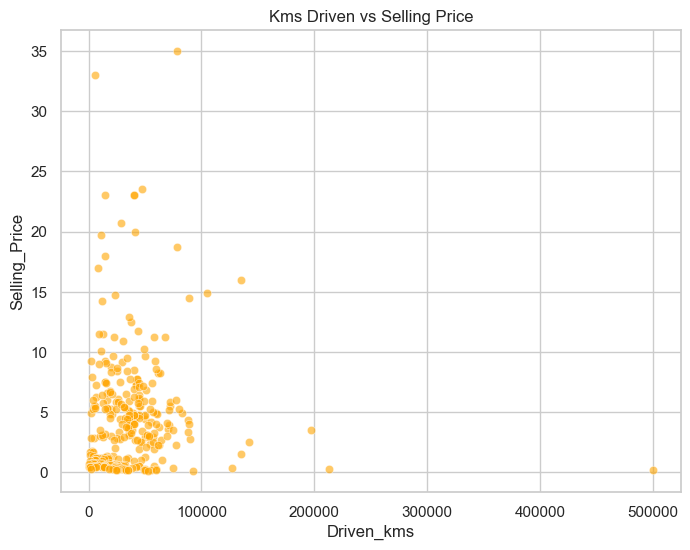

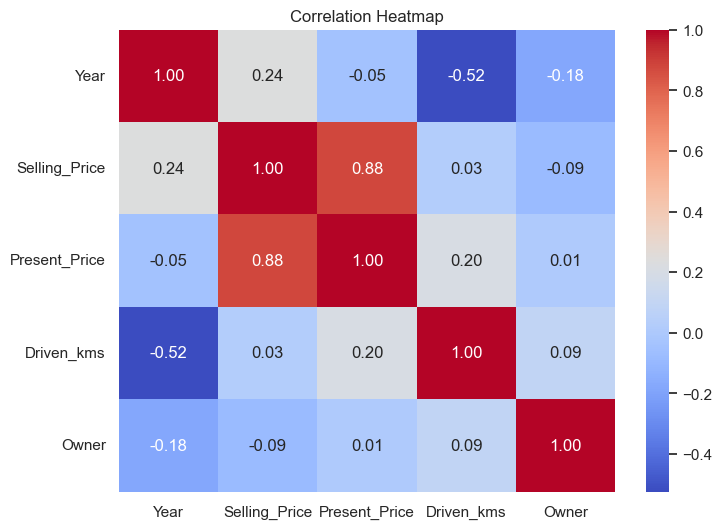

In [86]:
# Present Price vs Selling Price
sns.scatterplot(x='Present_Price', y='Selling_Price', data=data, alpha=0.6)
plt.title("Present Price vs Selling Price")
plt.show()

# Kms Driven vs Selling Price
sns.scatterplot(x='Driven_kms', y='Selling_Price', data=data, alpha=0.6, color="orange")
plt.title("Kms Driven vs Selling Price")
plt.show()

# Correlation heatmap
corr = data.corr(numeric_only=True)   # only numeric columns
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Step 7: Insights & Observations
- Car selling prices vary widely, with a skew towards lower-priced vehicles.  
- Present Price shows a strong positive correlation with Selling Price (higher present price → higher selling price).  
- Kms Driven tends to negatively correlate with Selling Price (more kilometers → lower resale value).  
- Fuel type, transmission, and seller type categories also influence price distribution.  
- Year of manufacture impacts price — newer cars generally sell for higher prices.  

## Step 8: Data Preprocessing & Baseline Model

In [88]:
## Step 8: Data Preprocessing & Baseline Model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np

# Select features and target
X = data[['Year','Present_Price','Driven_kms','Owner','Fuel_Type','Selling_type','Transmission']]
y = data['Selling_Price']

# Convert categorical variables into dummy/indicator variables
X = pd.get_dummies(X, drop_first=True)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train baseline Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred = lr_model.predict(X_test)

# Evaluation metrics
print("R² Score:", r2_score(y_test, y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)


R² Score: 0.8488707839193601
RMSE: 1.8658375680939612


## Step 9: Advanced Model - Random Forest Regressor

In [89]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation metrics
print("R² Score (Random Forest):", r2_score(y_test, y_pred_rf))

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("RMSE (Random Forest):", rmse_rf)

R² Score (Random Forest): 0.9627505225548417
RMSE (Random Forest): 0.9263171627604602


## Step 10: Model Comparison & Feature Importance

Linear Regression R²: 0.8488707839193601
Linear Regression RMSE: 1.8658375680939612
Random Forest R²: 0.9627505225548417
Random Forest RMSE: 0.9263171627604602


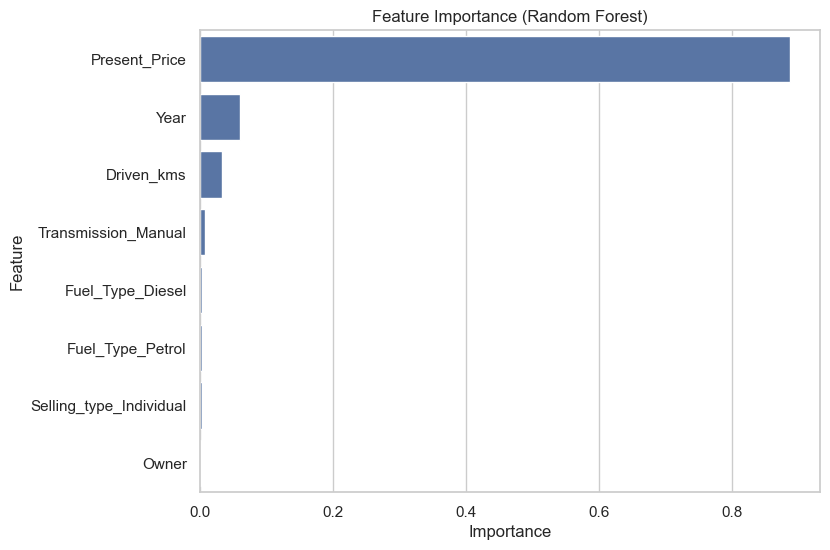

In [90]:
# Compare R² and RMSE between models
print("Linear Regression R²:", r2_score(y_test, y_pred))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

print("Random Forest R²:", r2_score(y_test, y_pred_rf))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

# Feature importance from Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for better visualization
feat_importances = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_importances = feat_importances.sort_values(by="Importance", ascending=False)

# Plot feature importance
sns.barplot(x="Importance", y="Feature", data=feat_importances)
plt.title("Feature Importance (Random Forest)")
plt.show()

## Step 11: Save Model & Deployment Prep

In [91]:
import joblib

# Save the Random Forest model
joblib.dump(rf_model, "car_price_rf_model.pkl")

# Save the Linear Regression model (optional)
joblib.dump(lr_model, "car_price_lr_model.pkl")

print("Models saved successfully!")

Models saved successfully!


## Step 12: Simple Prediction Demo

In [92]:
# Example input: a new car's details
sample_car = pd.DataFrame({
    'Year': [2018],
    'Present_Price': [7.5],
    'Kms_Driven': [35000],
    'Owner': [0],
    'Fuel_Type': ['Petrol'],
    'Seller_Type': ['Dealer'],
    'Transmission': ['Manual']
})

# Apply same preprocessing (dummy encoding)
sample_car = pd.get_dummies(sample_car, drop_first=True)

# Align columns with training data
sample_car = sample_car.reindex(columns=X.columns, fill_value=0)

# Predict using Random Forest
predicted_price = rf_model.predict(sample_car)
print("Predicted Selling Price:", predicted_price[0])

Predicted Selling Price: 6.179499999999998


In [93]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Ensure result folder exists
os.makedirs("result", exist_ok=True)

# Evaluate model
y_pred = rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# 1. Save metrics to text file
with open("result/model_metrics.txt", "w") as f:
    f.write(f"Random Forest RMSE: {rmse:.4f}\n")
    f.write(f"Random Forest R²: {r2:.4f}\n")

# 2. Save predictions vs actuals to CSV
pd.DataFrame({"Actual": y_test, "Predicted": y_pred}).to_csv("result/predictions.csv", index=False)

# 3. Save feature importance plot
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(8,6))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.tight_layout()
plt.savefig("result/feature_importance.png")
plt.close()

# 4. Save residuals plot
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals Plot")
plt.tight_layout()
plt.savefig("result/residuals_plot.png")
plt.close()

In [94]:
y_pred = rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

## Step 13: Deployment Demo (Streamlit Example)

In [95]:
import streamlit as st
import joblib
import pandas as pd

# Load saved model
model = joblib.load("car_price_rf_model.pkl")

st.title("Car Price Prediction App")

# User inputs
year = st.number_input("Year of Manufacture", min_value=2000, max_value=2025, value=2018)
present_price = st.number_input("Present Price (in lakhs)", min_value=0.0, value=7.5)
kms_driven = st.number_input("Kilometers Driven", min_value=0, value=35000)
owner = st.selectbox("Owner Count", [0,1,2,3])
fuel_type = st.selectbox("Fuel Type", ["Petrol","Diesel","CNG"])
seller_type = st.selectbox("Seller Type", ["Dealer","Individual"])
transmission = st.selectbox("Transmission", ["Manual","Automatic"])

# Prepare input
input_df = pd.DataFrame({
    'Year':[year],
    'Present_Price':[present_price],
    'Kms_Driven':[kms_driven],
    'Owner':[owner],
    'Fuel_Type':[fuel_type],
    'Seller_Type':[seller_type],
    'Transmission':[transmission]
})

input_df = pd.get_dummies(input_df, drop_first=True)
input_df = input_df.reindex(columns=model.feature_names_in_, fill_value=0)

# Prediction
if st.button("Predict Price"):
    prediction = model.predict(input_df)
    st.success(f"Predicted Selling Price: {prediction[0]:.2f} lakhs")

2026-06-14 00:09:40.110 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 00:09:40.110 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 00:09:40.111 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 00:09:40.112 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 00:09:40.113 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 00:09:40.114 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 00:09:40.114 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 00:09:40.115 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

## Step 14: Conclusion & Next Steps

- We successfully built a car price prediction pipeline:
  - Performed Exploratory Data Analysis (EDA).
  - Built baseline Linear Regression and advanced Random Forest models.
  - Compared performance using R² and RMSE.
  - Saved models for reuse and created a demo app for deployment.

### Key Insights
- Present Price and Year are the strongest predictors of Selling Price.
- Kms Driven negatively impacts resale value.
- Fuel Type, Transmission, and Seller Type also influence price distribution.

### Limitations
- Dataset may not represent all regions or newer car models.
- Predictions depend heavily on available features; missing attributes like mileage, brand reputation, or service history could improve accuracy.
- Current models are trained on a relatively small dataset, which may limit generalization.

### Real‑World Applications
- Helps car dealers estimate fair resale prices.
- Assists buyers in negotiating based on predicted value.
- Can be extended for insurance premium calculations or online resale platforms.

### Roadmap
- **Short‑Term:** Apply hyperparameter tuning (GridSearchCV/RandomizedSearchCV) to improve accuracy; experiment with Gradient Boosting and XGBoost.
- **Mid‑Term:** Expand dataset with more diverse regions, newer cars, and additional features.
- **Long‑Term:** Deploy the Streamlit app to a cloud platform (Streamlit Cloud, Heroku, AWS) with user authentication, database integration, and logging of predictions.
